# XGBoost Predictive Model

Imports

In [54]:
import pandas as pd
import numpy as np
import time
import os
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, accuracy_score, 
    confusion_matrix, fbeta_score
)
from sklearn.dummy import DummyClassifier
from sklearn.utils import resample
import matplotlib.pyplot as plt

Load tiers

In [55]:
from tiering_preparation import TIERS

tiers = {
    "Tier_1_Basic": TIERS["Tier_1_Basic"],
    "Tier_2_Clinical": TIERS["Tier_2_Clinical"],
    "Tier_3_Personalized": TIERS["Tier_3_Personalized"],
}

In [56]:
from pathlib import Path

# 🔒 HARD-ANCHOR PROJECT ROOT (EDIT THIS PATH ONCE)
PROJECT_ROOT = Path(
    r"C:\Users\agila\Documents\STM\Predicting-Past-Year-Major-Depressive-Episode"
)

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Saving results to:", RESULTS_DIR.resolve())


Saving results to: C:\Users\agila\Documents\STM\Predicting-Past-Year-Major-Depressive-Episode\results


Load dataset, drop weight from X, but SAVE w

In [57]:
df = pd.read_pickle("../data/prepared/NSDUH_2023_prepared.pkl")

TARGET = "IRAMDEYR"
WEIGHT = "ANALWT2_C"

y = df[TARGET]
w = df[WEIGHT]
X = df.drop(columns=[TARGET, WEIGHT])

Split train/test (consistent with feature selection)

In [58]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.2,
    stratify=y,
    random_state=42
)




Compute fixed class imbalance

In [59]:
pos = y_train.sum()
neg = len(y_train) - pos
SCALE_POS_WEIGHT = neg / pos

Define metric helper

In [60]:
def evaluate_model(y_true, preds, probs):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

    specificity = tn / (tn + fp)
    sensitivity = recall_score(y_true, preds)  # same as recall
    ppv = precision_score(y_true, preds)
    npv = tn / (tn + fn)

    return {
        "Accuracy": accuracy_score(y_true, preds),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "AUC": roc_auc_score(y_true, probs),
        "F1": fbeta_score(y_true, preds, beta=1),
        "F2": fbeta_score(y_true, preds, beta=2),
    }

XGBoost Pipeline w/ Weighted Fitting + RandomizedSearchCV

In [61]:
param_grid = {
    "clf__n_estimators": [50, 100, 150, 200],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.01, 0.05, 0.1],     
    "clf__subsample": [0.8, 1.0],
    "clf__scale_pos_weight": [1, 9],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
def build_model():
    pipe = Pipeline([
        ("clf", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            enable_categorical=True,
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ])

    model = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=20,
        scoring="recall",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=2
    )

    return model

Bootstrapped Confidence Intervals (ROC + PR)

In [62]:
def bootstrap_auc_ci(model, X, y, n_boot=1000):
    aucs = []

    for _ in range(n_boot):
        X_bs, y_bs = resample(X, y, replace=True)
        probs = model.predict_proba(X_bs)[:, 1]
        aucs.append(roc_auc_score(y_bs, probs))

    return np.percentile(aucs, [2.5, 97.5])


Baseline Model (Dummy Classifier)

In [63]:
# dummy = DummyClassifier(strategy="most_frequent")
# dummy.fit(X_train, y_train)
# dummy_preds = dummy.predict(X_test)
# dummy_probs = np.zeros_like(dummy_preds)

# dummy_metrics = evaluate_model(y_test, dummy_preds, dummy_probs)

Train + Evaluate XGBoost on Each tier

In [64]:
results = []
best_models = {}

for tier_name, features in tiers.items():

    print(f"\n----- Training XGBoost on {tier_name} ({len(features)} features) -----")
    
    start_time = time.time()

    Xtr = X_train[features]
    Xte = X_test[features]

    model = build_model()

    # Fit WITH survey weights
    model.fit(Xtr, y_train, clf__sample_weight=w_train)

    # Save best model for fold-wise CV later
    best_models[tier_name] = model.best_estimator_

    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1]

    metrics = evaluate_model(y_test, preds, probs)

    # Bootstrapped CI
    ci_low, ci_high = bootstrap_auc_ci(model, Xte, y_test)

    metrics["tier"] = tier_name
    metrics["threshold"] = 0.50
    metrics["n_features"] = len(features)
    metrics["AUC_CI_Low"] = ci_low
    metrics["AUC_CI_High"] = ci_high
    metrics["Best_Params"] = str(model.best_params_)

    results.append(metrics)
    
    print(f"Best params: {model.best_params_}")
    print(f"Completed in {time.time() - start_time:.1f} seconds")


----- Training XGBoost on Tier_1_Basic (6 features) -----
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'clf__subsample': 1.0, 'clf__scale_pos_weight': 9, 'clf__n_estimators': 50, 'clf__max_depth': 3, 'clf__learning_rate': 0.05}
Completed in 77.4 seconds

----- Training XGBoost on Tier_2_Clinical (10 features) -----
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'clf__subsample': 1.0, 'clf__scale_pos_weight': 9, 'clf__n_estimators': 50, 'clf__max_depth': 3, 'clf__learning_rate': 0.05}
Completed in 71.7 seconds

----- Training XGBoost on Tier_3_Personalized (19 features) -----
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'clf__subsample': 1.0, 'clf__scale_pos_weight': 9, 'clf__n_estimators': 50, 'clf__max_depth': 3, 'clf__learning_rate': 0.05}
Completed in 93.4 seconds


Convert to DataFrame + Export

In [65]:
# 5-Fold Cross-Validation on TRAIN set (no test leakage)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics_order = ["Accuracy", "Sensitivity", "Specificity", "PPV", "NPV", "AUC", "F1", "F2"]

all_fold_dfs = []

for tier_name, features in tiers.items():
    print(f"\n===== {tier_name} =====")
    
    fold_rows = []
    best_model = best_models[tier_name]
    
    X_tier = X_train[features]
    w_tier = w_train
    
    for fold_i, (tr_idx, val_idx) in enumerate(skf.split(X_tier, y_train), start=1):
        Xtr_fold, Xval_fold = X_tier.iloc[tr_idx], X_tier.iloc[val_idx]
        ytr_fold, yval_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        wtr_fold = w_tier.iloc[tr_idx]
        
        model_clone = clone(best_model)
        model_clone.fit(Xtr_fold, ytr_fold, clf__sample_weight=wtr_fold)
        
        preds = model_clone.predict(Xval_fold)
        probs = model_clone.predict_proba(Xval_fold)[:, 1]
        
        fold_metrics = evaluate_model(yval_fold, preds, probs)
        fold_metrics["Fold"] = f"Fold {fold_i}"
        fold_rows.append(fold_metrics)
    
    # Table: rows=Metric, cols=Fold1..Fold5 (TRANSPOSE like LightGBM)
    fold_df = pd.DataFrame(fold_rows).set_index("Fold")[metrics_order].T
    fold_df["Mean"] = fold_df.mean(axis=1)
    fold_df["Std Dev"] = fold_df.std(axis=1)
    fold_df.insert(0, "Tier", tier_name)
    fold_df = fold_df.reset_index().rename(columns={"index": "Metric"})
    
    all_fold_dfs.append(fold_df)
    print(fold_df)

# Combine and export
cv_results_df = pd.concat(all_fold_dfs, ignore_index=True)

print("\nSaved: xgb_5fold_threshold0.50_by_tier.csv")


===== Tier_1_Basic =====
Fold       Metric          Tier    Fold 1    Fold 2    Fold 3    Fold 4  \
0        Accuracy  Tier_1_Basic  0.558941  0.532761  0.601717  0.568526   
1     Sensitivity  Tier_1_Basic  0.724656  0.783750  0.707500  0.736250   
2     Specificity  Tier_1_Basic  0.537555  0.500323  0.588045  0.546850   
3             PPV  Tier_1_Basic  0.168216  0.168548  0.181643  0.173542   
4             NPV  Tier_1_Basic  0.937993  0.947095  0.939597  0.941324   
5             AUC  Tier_1_Basic  0.693584  0.709003  0.714747  0.701434   
6              F1  Tier_1_Basic  0.273049  0.277434  0.289070  0.280877   
7              F2  Tier_1_Basic  0.436125  0.453035  0.448068  0.446618   

Fold    Fold 5      Mean   Std Dev  
0     0.624696  0.577328  0.032374  
1     0.685857  0.727603  0.032811  
2     0.616801  0.557915  0.040569  
3     0.187671  0.175924  0.007618  
4     0.938314  0.940865  0.003328  
5     0.716441  0.707042  0.008533  
6     0.294703  0.283027  0.007853  
7 

In [66]:
import os

cv_results_df.to_csv(
    RESULTS_DIR / "xgb_5fold_threshold0.50_by_tier.csv",
    index=False
)


print("✅ Saved: ./results/xgb_5fold_threshold0.50_by_tier.csv")
print("Rows:", len(cv_results_df))
print(cv_results_df.head())

✅ Saved: ./results/xgb_5fold_threshold0.50_by_tier.csv
Rows: 24
Fold       Metric          Tier    Fold 1    Fold 2    Fold 3    Fold 4  \
0        Accuracy  Tier_1_Basic  0.558941  0.532761  0.601717  0.568526   
1     Sensitivity  Tier_1_Basic  0.724656  0.783750  0.707500  0.736250   
2     Specificity  Tier_1_Basic  0.537555  0.500323  0.588045  0.546850   
3             PPV  Tier_1_Basic  0.168216  0.168548  0.181643  0.173542   
4             NPV  Tier_1_Basic  0.937993  0.947095  0.939597  0.941324   

Fold    Fold 5      Mean   Std Dev  
0     0.624696  0.577328  0.032374  
1     0.685857  0.727603  0.032811  
2     0.616801  0.557915  0.040569  
3     0.187671  0.175924  0.007618  
4     0.938314  0.940865  0.003328  


In [67]:
results_df = pd.DataFrame(results)

# Reorder columns to match LightGBM format
front_cols = ["tier", "threshold", "n_features"]
other_cols = [c for c in results_df.columns if c not in front_cols]
results_df = results_df[front_cols + other_cols]

results_df.to_csv("./results/xgb_two_rows_per_tier.csv", index=False)

print(results_df)

OSError: Cannot save file into a non-existent directory: 'results'

SHAP Analysis


===== Tier_1_Basic =====


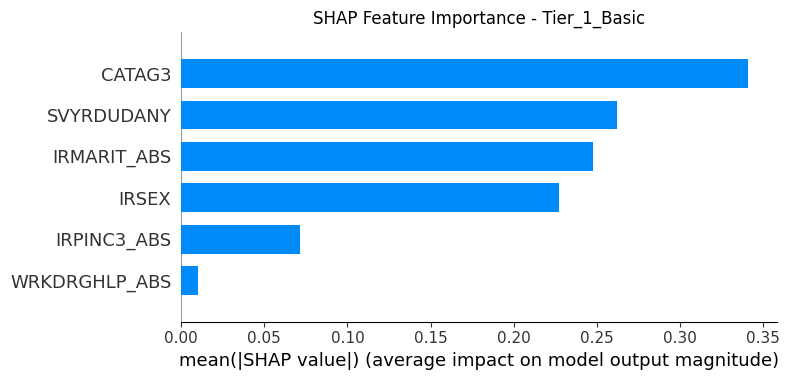

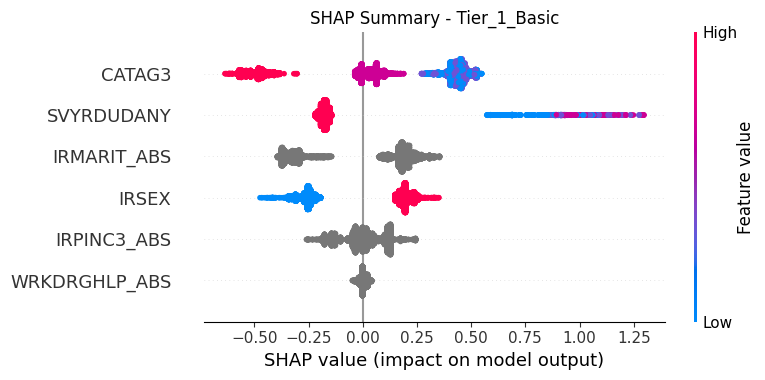


Top 10 Features by SHAP:
      feature  mean_abs_shap         tier  rank
       CATAG3       0.341068 Tier_1_Basic     1
   SVYRDUDANY       0.262221 Tier_1_Basic     2
  IRMARIT_ABS       0.247915 Tier_1_Basic     3
        IRSEX       0.227461 Tier_1_Basic     4
  IRPINC3_ABS       0.071741 Tier_1_Basic     5
WRKDRGHLP_ABS       0.010195 Tier_1_Basic     6


<Figure size 800x500 with 0 Axes>

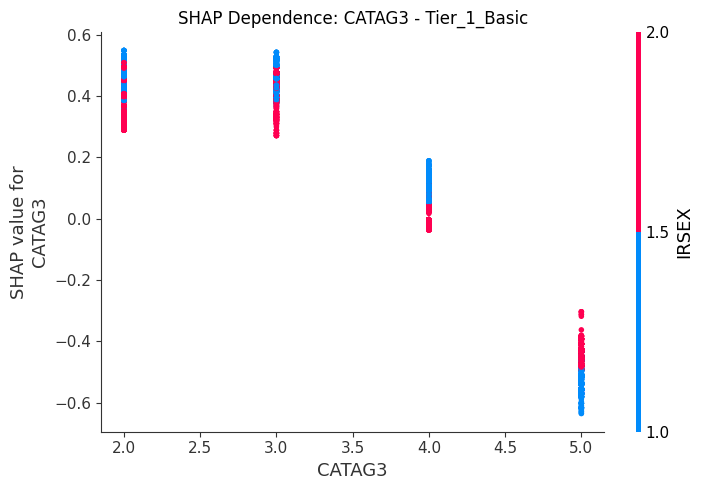

<Figure size 800x500 with 0 Axes>

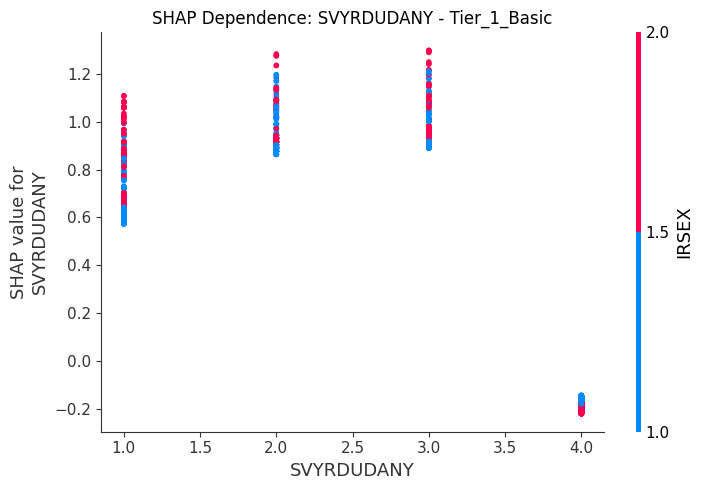

<Figure size 800x500 with 0 Axes>

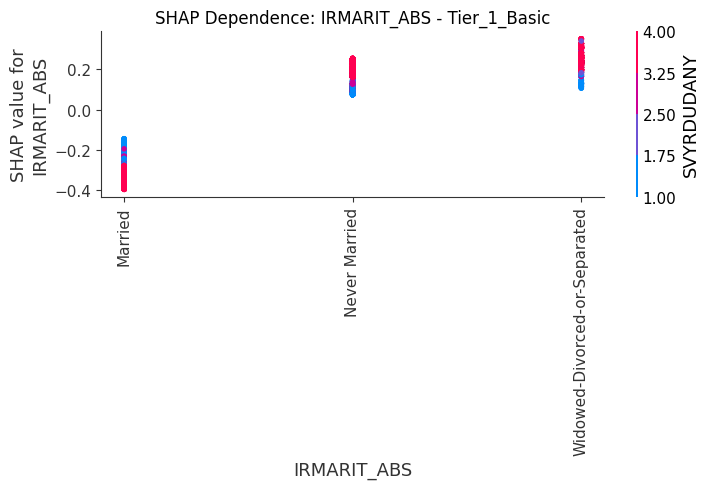


===== Tier_2_Clinical =====


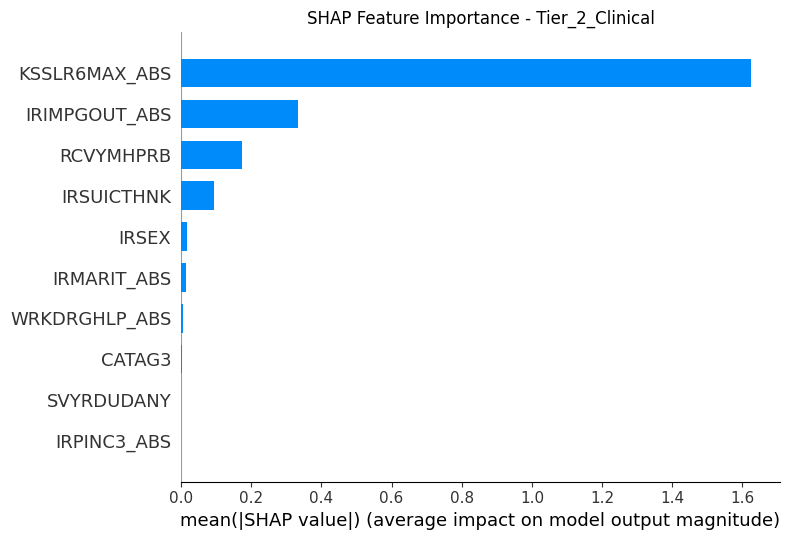

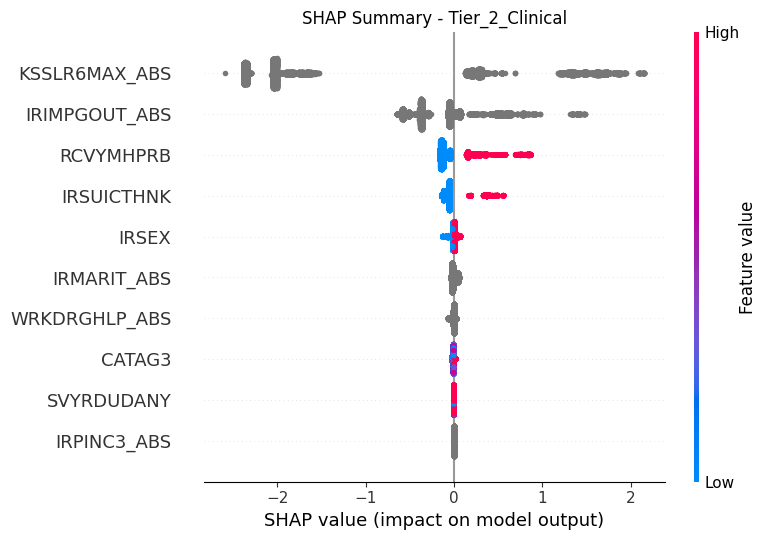


Top 10 Features by SHAP:
      feature  mean_abs_shap            tier  rank
KSSLR6MAX_ABS       1.625626 Tier_2_Clinical     1
IRIMPGOUT_ABS       0.334070 Tier_2_Clinical     2
    RCVYMHPRB       0.173065 Tier_2_Clinical     3
   IRSUICTHNK       0.093117 Tier_2_Clinical     4
        IRSEX       0.015487 Tier_2_Clinical     5
  IRMARIT_ABS       0.014273 Tier_2_Clinical     6
WRKDRGHLP_ABS       0.004962 Tier_2_Clinical     7
       CATAG3       0.003675 Tier_2_Clinical     8
   SVYRDUDANY       0.000000 Tier_2_Clinical     9
  IRPINC3_ABS       0.000000 Tier_2_Clinical    10


<Figure size 800x500 with 0 Axes>

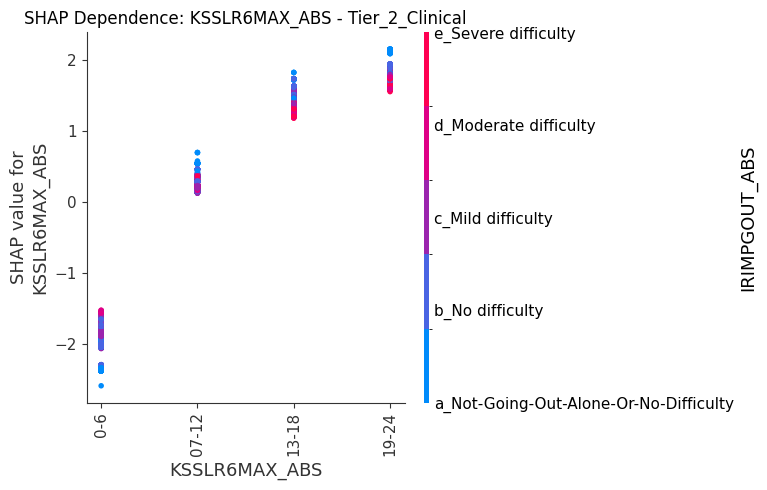

<Figure size 800x500 with 0 Axes>

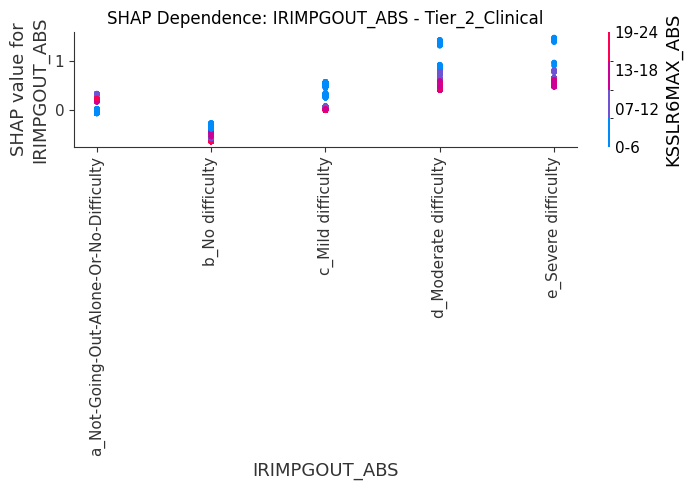

<Figure size 800x500 with 0 Axes>

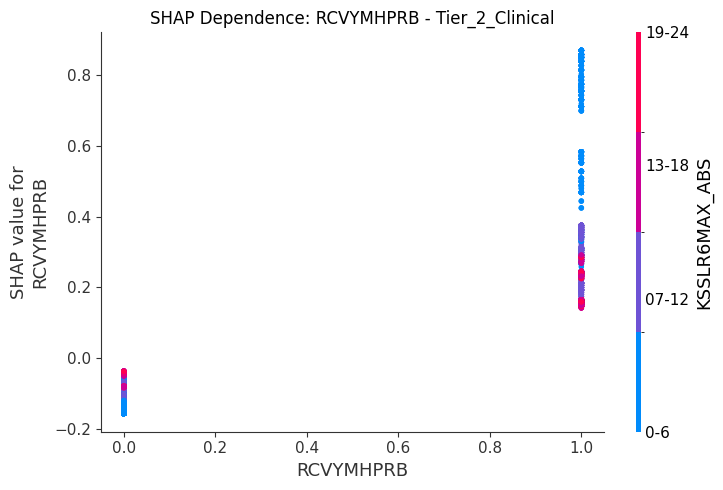


===== Tier_3_Personalized =====


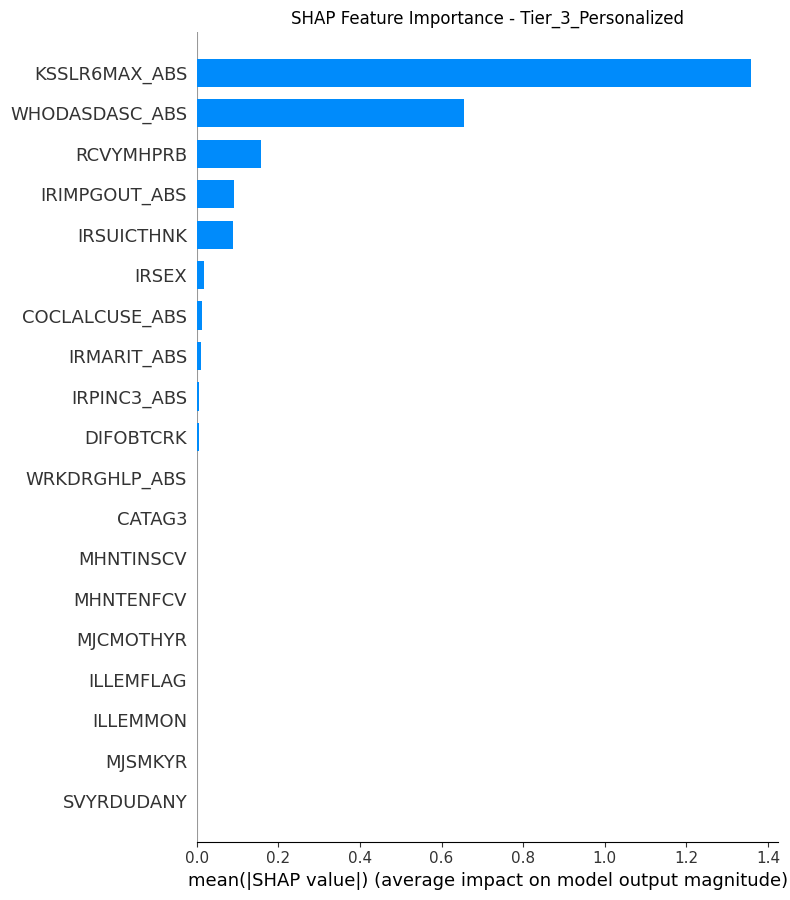

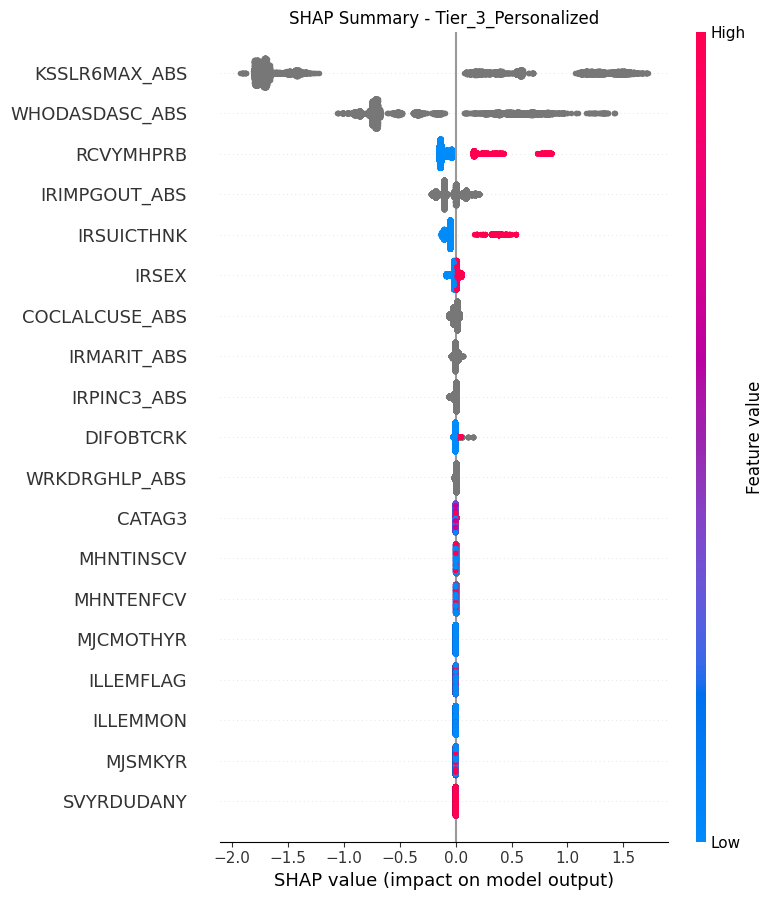


Top 10 Features by SHAP:
       feature  mean_abs_shap                tier  rank
 KSSLR6MAX_ABS       1.357722 Tier_3_Personalized     1
WHODASDASC_ABS       0.653802 Tier_3_Personalized     2
     RCVYMHPRB       0.158053 Tier_3_Personalized     3
 IRIMPGOUT_ABS       0.090075 Tier_3_Personalized     4
    IRSUICTHNK       0.089366 Tier_3_Personalized     5
         IRSEX       0.018302 Tier_3_Personalized     6
COCLALCUSE_ABS       0.013641 Tier_3_Personalized     7
   IRMARIT_ABS       0.009763 Tier_3_Personalized     8
   IRPINC3_ABS       0.006501 Tier_3_Personalized     9
     DIFOBTCRK       0.006431 Tier_3_Personalized    10


<Figure size 800x500 with 0 Axes>

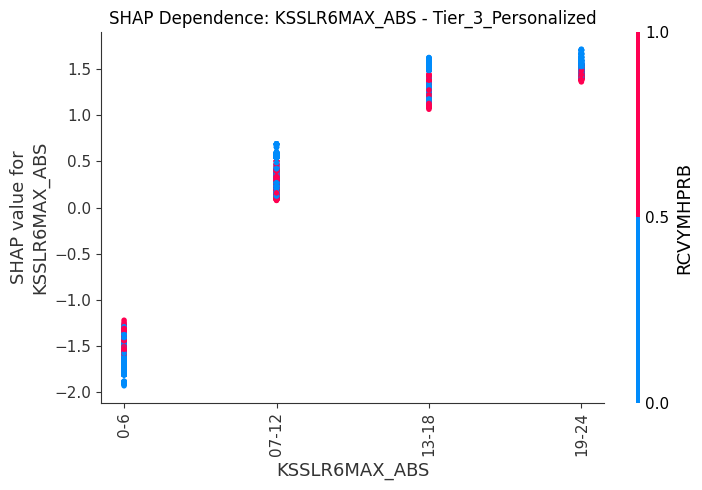

<Figure size 800x500 with 0 Axes>

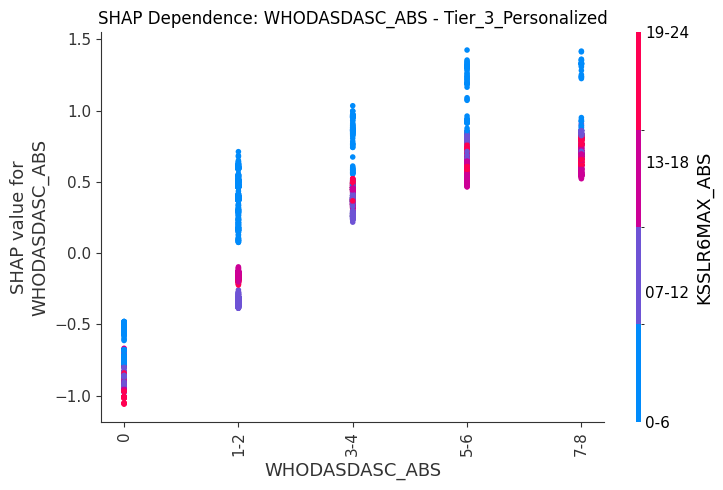

<Figure size 800x500 with 0 Axes>

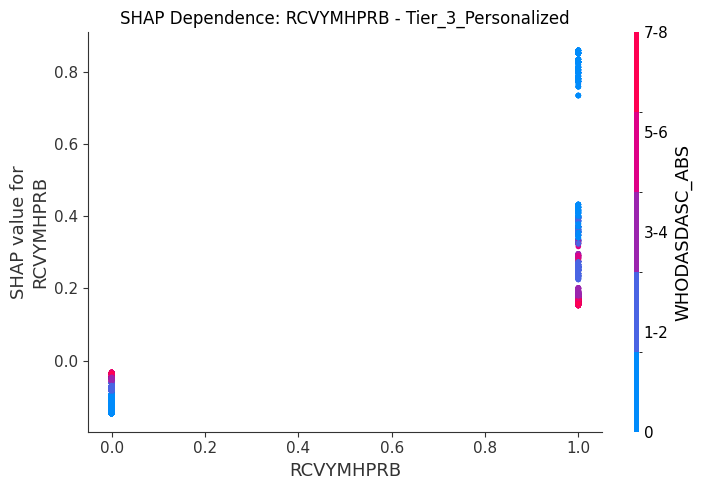


SHAP analysis complete


In [ ]:
# SHAP Analysis for XGBoost
import shap
import os

os.makedirs("./results/figures", exist_ok=True)

shap_importance_all = []

for tier_name, features in tiers.items():
    print(f"\n===== {tier_name} =====")
    
    best_model = best_models[tier_name]
    clf = best_model.named_steps["clf"]  # only step now
    
    # Use raw test data (NO IMPUTATION)
    X_tier_test = X_test[features]

    # TreeExplainer for XGBoost
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_tier_test)
    
    # --- Global importance (bar plot) ---
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values,
        X_tier_test,
        plot_type="bar",
        show=False
    )
    plt.title(f"SHAP Feature Importance - {tier_name}")
    plt.tight_layout()
    plt.savefig(
        f"./results/figures/xgb_shap_importance_{tier_name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    
    # --- Beeswarm plot ---
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values,
        X_tier_test,
        show=False
    )
    plt.title(f"SHAP Summary - {tier_name}")
    plt.tight_layout()
    plt.savefig(
        f"./results/figures/xgb_shap_beeswarm_{tier_name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    
    # --- Feature importance table ---
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    shap_importance = pd.DataFrame({
        "feature": features,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)
    
    shap_importance["tier"] = tier_name
    shap_importance["rank"] = range(1, len(features) + 1)
    shap_importance_all.append(shap_importance)
    
    print("\nTop 10 Features by SHAP:")
    print(shap_importance.head(10).to_string(index=False))
    
    # --- Dependence plots (top 3 features) ---
    top_features = shap_importance["feature"].head(3).tolist()
    for i, feat in enumerate(top_features, start=1):
        plt.figure(figsize=(8, 5))
        shap.dependence_plot(
            feat,
            shap_values,
            X_tier_test,
            show=False
        )
        plt.title(f"SHAP Dependence: {feat} - {tier_name}")
        plt.tight_layout()
        plt.savefig(
            f"./results/figures/xgb_shap_dependence_{tier_name}_top{i}_{feat}.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()
    
    # --- Save SHAP values ---
    shap_df = pd.DataFrame(shap_values, columns=features, index=X_tier_test.index)
    shap_df.to_csv(
        f"./results/xgb_shap_values_{tier_name}.csv"
    )

# --- Combined importance table ---
shap_importance_combined = pd.concat(shap_importance_all, ignore_index=True)
shap_importance_combined = shap_importance_combined[
    ["tier", "rank", "feature", "mean_abs_shap"]
]
shap_importance_combined.to_csv(
    "./results/xgb_shap_importance_by_tier.csv",
    index=False
)

print("\nSHAP analysis complete")